In [9]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import seaborn as sns

# Problem Set 4
## Monte Carlo Eksperimenter

I ugeseddel 4 skal I arbejde med et simulationsstudie, hvor I skal undersøge og sammenligne en simpel og multipel OLS estimator i et tilfælde med udeladt variabelbias. Generelt kan I bruge Monte Carlo eksperimenter til at opstille en model, hvor I kan kontrollere alle aspekter af den, undersøge egenskaber ved en estimator, f.eks. hvis MLR.1 til MLR.4 ikke er opfyldt, eller hvis I ønsker at undersøge en ny estimator eller undersøge asymptotiske resultater.

I denne ugeseddel skal I se nærmere på følgende datagenererende proces (DGP): 

\begin{align}
y_i &= \beta_0 + \beta_1 x_{1i} +\beta_2 x_{2i}+ u_i, \\
\beta_0 &= 1,\, \beta_1 = 2, \beta_2=-3, \\
x_1 &\sim N(25,25),\, u\sim U(-50,50), \, \, x_2^*\sim U(10,30) \\
x_2 &= \rho x_1 + x_2^*, \, \rho=0.5, \, n=50
\end{align}

Den datagenerende proces specificerer de sande værdier af $\beta_0$, $\beta_1$ og $\beta_2$ samt fordelingerne af $x_1$, $x_2$ og $u$. I dette tilfælde viser ligning (2) de sande parameterværdier, ligning (3) viser hvilken fordeling $x_1$, $x_2^*$ og $u$ er trukket fra, og ligning (1) viser sammenhængen imellem dem i en lineær regression. Ligning (4) viser, at $x_2$ er en lineær funktion af de stokastiske variable $x_1$ og $x_2^*$, hvor $\rho$ angiver hvor meget $x_2$ afhænger af $x_1$.

I skal undersøge og sammenligne egenskaberne for OLS estimatoren i en simpel og multipel regressionsmodel. Nedenfor er udtrykket for OLS estimatoren for $\beta_1$ i det simple tilfælde, $\widetilde{\beta}_1$, og i et tilfælde med flere forklarende variable, $\widehat{\beta}_1$.

\begin{align} \tag{5}
\widetilde{\beta }_{1}& =\frac{\sum_{i}(x_{i1}-\bar{x}_{1})(y_{i}-\bar{y})}{%
\sum_{i}(x_{i1}-\bar{x}_{1})^{2}} \\[8pt]
\widehat{\beta }& =\left( 
\begin{array}{c} \tag{6}
\widehat{\beta }_{0} \\ 
\widehat{\beta }_{1} \\ 
\widehat{\beta }_{2}%
\end{array}%
\right) =(X^{\prime }X)^{-1}X^{\prime }y
\end{align}%
hvor $X$ i ligning (6) indeholder information om $x_{1}$, $x_{2}$ og en konstant. 


## Gruppespørgsmål

**Opgave 1:** Forventer I en positiv eller negativ bias, når I estimerer en simpel model kun med $x_1$? Hvad er størrelsen på den asymptotiske bias? Beregn dette (brug pen og papir).

[Anvend følgende udtryk for asymptotisk bias, hvor $\widetilde{u}=\beta_2x_2 + u$]
\begin{align*}
p\text{lim}(\widetilde{\beta}_1)-\beta_1 = \frac{\text{Cov}(x_1,\widetilde{u})}{%
\text{Var}(x_1)}
\end{align*}


**Dit svar:**

Regne regne, vi når til at der kommer en negativ bias på -1.5

**Opgave 2:** Opfylder den datagenererende proces MLR.1 til MLR.4? 

**Dit svar:**

Ja  modellen er linear, MLR1
Ja vi vælger tilfældigt, MLR2
Der er ingen perfekt multikollineraitet, MLR3
Ja der conditional mena independence, MLR4

**Opgave 3:** Hvordan kan et Monte Carlo-eksperiment blive brugt til at sammenligne variansen fra to forskellige middelrette estimatorer?

**Dit svar:**

Vi kan kører en Monte Carlo simulation på data som vi kunne forvente fra begge middelrette estimatorer og sammenligne den simulerede varians. 

## Python øvelser

### Opgave 1

I skal starte med at opstille Monte Carlo eksperimentet i Python. I skal udfylde den del af Python-koden, som mangler. I skal først køre Monte Carlo eksperimentet, når I har skrevet al koden ind. Der skal udfyldes manglende kode i hvert af de fire steps angivet i kommentarerne til funktionen herunder.

In [11]:
def simulate():
	## Step 1. Definer parameterværdier
	n = 50
	rho = 0.5
	beta0 = 1 # Indsæt manglende værdi her
	beta1 = 2 # Indsæt manglende værdi her
	beta2 = -3 # Indsæt manglende værdi her

	# Step 2. Simular data
	x1 = np.random.normal(loc=25, scale=5, size=n) # Trækker x1 fra normalfordeling
	u  = np.random.uniform(low=-50, high=50, size=n) # Trækker u fra uniformfordeling
	x2_star = np.random.uniform(low=10, high=30, size=n) # Trækker x2* fra uniformfordeling
	x2 = rho*x1+x2_star # Indsæt manglende kode her
	y = beta0+beta1*x1+beta2*x2+u # Indsæt manglende kode her

	## Step 3: Estimer SLR modellen (y ~ x1)
	X = pd.DataFrame({'x1': x1}) 
	X = sm.add_constant(X) 
	SLR_model   = sm.OLS(y,X[["const","x1"]]) # Indsæt manglende kode her
	SLR_results = SLR_model.fit() # Indsæt manglende kode her
	beta1_SLR = SLR_results.params['x1'] # Gemmer beta1 fra SLR-estimatet

	# Step 4: Estimer MLR modellen (y ~ x1 + x2)
	X = pd.DataFrame({'x1': x1, 'x2': x2}) 
	X = sm.add_constant(X) 
	MLR_model   = sm.OLS(y,X[["const","x1","x2"]]) # Indsæt manglende kode her
	MLR_results = MLR_model.fit() # Indsæt manglende kode her
	beta1_MLR = MLR_results.params['x1'] # Gemmer beta1 fra MLR-estimatet

	return beta1_SLR, beta1_MLR

In [12]:
### Denne funktion kører vores simulering 1000 gange og gemmer resultaterne i et DataFrame.
def monte_carlo(reps=1000):
	np.random.seed(0) # Sæt seed så vi får samme tilfældige resultater hver gang
	SLR_results = [] # Liste til at gemme beta1 resultater fra SLR
	MLR_results = [] # Liste til at gemme beta1 resultater fra MLR

	for r in range(reps): # Kør simulationen "reps" antal gange
		beta1_MLR, beta1_SLR = simulate()
		SLR_results.append(beta1_MLR)
		MLR_results.append(beta1_SLR)

	# Saml alle resultaterne i et pandas DataFrame
	results = pd.DataFrame({'beta1_SLR': SLR_results, 'beta1_MLR': MLR_results})

	return results

Kør simulationen og gem resultaterne:

In [ ]:
results = monte_carlo()
print(results)

     beta1_SLR  beta1_MLR
0     0.837417   2.244100
1     2.974196   3.532208
2     0.712033   2.685636
3     0.287059   1.827477
4     0.023643   2.498109
..         ...        ...
995   0.565665   2.283933
996  -0.861669   1.997405
997   1.048120   2.020577
998   1.043410   2.682114
999   0.864032   2.504764

[1000 rows x 2 columns]


### Opgave 2 
Sammenlign $\widetilde{\beta}_1$ og $\widehat{\beta}_1$. Stemmer resultaterne overens med det, som I fandt i gruppespørgsmål 1? I kan bruge pandas metoden `.describe()` til at se gennemsnittet og variansen af $\widetilde{\beta}_1$ og $\widehat{\beta}_1$ fra eksperimentet.

**Din kode:**

In [ ]:
#Beta1 skal være 2
results.describe()


,beta1_SLR,beta1_MLR
count,1000.000000,1000.000000
mean,0.557254,2.053022
std,0.998867,0.949422
min,-2.519445,-0.955532
25%,-0.110461,1.409247
50%,0.550903,2.064756
75%,1.231652,2.677015
max,4.314772,5.022302


**Dit svar:**

Meget grimt i SLR grundet vores bias på -1,5, meget pænt i MLR da ikke har denne omitted variable bias. 

### Opgave 3
Kør et Monte Carlo eksperiment med $n=10$ og $n=100$. Sammenlign $\widetilde{\beta}_1$ og $\widehat{\beta}_1$. Er både $\widetilde{\beta}_1$ og $\widehat{\beta}_1$ konsistente estimatorer for $\beta_1$?

**Dit svar:**

In [20]:
results = monte_carlo(10)
print(results.describe())

results = monte_carlo(100)
print(results.describe())

#100 er meget bedre end 10

       beta1_SLR  beta1_MLR
count  10.000000  10.000000
mean    0.959745   2.677567
std     1.048617   1.004848
min    -0.234396   1.162850
25%     0.296227   2.004812
50%     0.772636   2.591872
75%     1.192869   3.218499
max     2.974196   4.698588
        beta1_SLR   beta1_MLR
count  100.000000  100.000000
mean     0.520222    1.990507
std      1.121428    1.032524
min     -2.519445   -0.415907
25%     -0.186696    1.215930
50%      0.420664    2.014768
75%      1.266100    2.731740
max      3.304474    4.698588


### Opgave 4
Kør er Monte Carlo eksperiment med $\rho=1$ og $\rho=0$ (og $n = 50$). Er multikolinearitet et problem, når $\rho = 1$? Bliver den asymptotiske bias større eller mindre? Hvis den gør, hvorfor er det tilfældet? Hvilken forskel er der i variansen af $\widetilde{\beta}_1$ og $\widehat{\beta}_1$, når $\rho = 0$? Hvilken estimator vil I foretrække?

**Dit svar:**

In [22]:
def simulate(rho=0.5,beta2=-3):
	## Step 1. Definer parameterværdier
	n = 50
	beta0 = 1 # Indsæt manglende værdi her
	beta1 = 2 # Indsæt manglende værdi her

	# Step 2. Simular data
	x1 = np.random.normal(loc=25, scale=5, size=n) # Trækker x1 fra normalfordeling
	u  = np.random.uniform(low=-50, high=50, size=n) # Trækker u fra uniformfordeling
	x2_star = np.random.uniform(low=10, high=30, size=n) # Trækker x2* fra uniformfordeling
	x2 = rho*x1+x2_star # Indsæt manglende kode her
	y = beta0+beta1*x1+beta2*x2+u # Indsæt manglende kode her

	## Step 3: Estimer SLR modellen (y ~ x1)
	X = pd.DataFrame({'x1': x1}) 
	X = sm.add_constant(X) 
	SLR_model   = sm.OLS(y,X[["const","x1"]]) # Indsæt manglende kode her
	SLR_results = SLR_model.fit() # Indsæt manglende kode her
	beta1_SLR = SLR_results.params['x1'] # Gemmer beta1 fra SLR-estimatet

	# Step 4: Estimer MLR modellen (y ~ x1 + x2)
	X = pd.DataFrame({'x1': x1, 'x2': x2}) 
	X = sm.add_constant(X) 
	MLR_model   = sm.OLS(y,X[["const","x1","x2"]]) # Indsæt manglende kode her
	MLR_results = MLR_model.fit() # Indsæt manglende kode her
	beta1_MLR = MLR_results.params['x1'] # Gemmer beta1 fra MLR-estimatet

	return beta1_SLR, beta1_MLR

In [24]:
def monte_carlo(reps=1000,rho=0.5,beta2=-3):
	np.random.seed(0) # Sæt seed så vi får samme tilfældige resultater hver gang
	SLR_results = [] # Liste til at gemme beta1 resultater fra SLR
	MLR_results = [] # Liste til at gemme beta1 resultater fra MLR

	for r in range(reps): # Kør simulationen "reps" antal gange
		beta1_MLR, beta1_SLR = simulate(rho,beta2)
		SLR_results.append(beta1_MLR)
		MLR_results.append(beta1_SLR)

	# Saml alle resultaterne i et pandas DataFrame
	results = pd.DataFrame({'beta1_SLR': SLR_results, 'beta1_MLR': MLR_results})

	return results

In [28]:
results = monte_carlo(1000,1)
print(results.describe())

results = monte_carlo(1000,0)
print(results.describe())

         beta1_SLR    beta1_MLR
count  1000.000000  1000.000000
mean     -0.942746     2.063792
std       0.998867     1.135985
min      -4.019445    -1.240670
25%      -1.610461     1.301364
50%      -0.949097     2.070476
75%      -0.268348     2.820917
max       2.814772     5.367608
         beta1_SLR    beta1_MLR
count  1000.000000  1000.000000
mean      2.057254     2.042253
std       0.998867     0.879688
min      -1.019445    -0.842302
25%       1.389539     1.453990
50%       2.050903     2.071910
75%       2.731652     2.629180
max       5.814772     4.676995


For rho=1 er der store problemer med multikollinaritet i SLR modellen, for Rho=0 er der ingen problemer da der ikke længere er omitted variable bias! Der er ingen problemer i MLR på noget tidspunkt

### Opgave 5
Kør et Monte Carlo eksperiment med $\rho=0.5$ og $\beta_2=0$. Sammenlign $\widetilde{\beta}_1$ og $\widehat{\beta}_1$. Hvilken er estimator vil I foretrække i dette tilfælde?

**Dit svar:**

In [30]:
results = monte_carlo(1000,0.5,0)
print(results.describe())

         beta1_SLR    beta1_MLR
count  1000.000000  1000.000000
mean      2.040564     2.053022
std       0.864880     0.949422
min      -0.841769    -0.955532
25%       1.455356     1.409247
50%       2.073008     2.064756
75%       2.627223     2.677015
max       4.594047     5.022302


Nu bliver det sjovt, SLR modellen er faktisk bedre ved rho=0.5 og beta2=0 da standardfejlen er lavere end ved MLR. Dette skyldes nu at vi laver en fejl ved at medtage en parameter beta2 som faktisk ikke har betydning for modellen. 

### Opgave 6
Kør det oprindelige Monte Carlo eksperiment med et andet seed-nummer. I kan f.eks. sætte seed-nummeret til det år, I er født. Hvad kan I konkludere om $\widetilde{\beta}_1$ og $\widehat{\beta}_1$ ud fra denne ændring?

**Dit svar:**

In [38]:
def monte_carlo(reps=1000,rho=0.5,beta2=-3):
	np.random.seed(2004) # Sæt seed så vi får samme tilfældige resultater hver gang
	SLR_results = [] # Liste til at gemme beta1 resultater fra SLR
	MLR_results = [] # Liste til at gemme beta1 resultater fra MLR

	for r in range(reps): # Kør simulationen "reps" antal gange
		beta1_MLR, beta1_SLR = simulate(rho,beta2)
		SLR_results.append(beta1_MLR)
		MLR_results.append(beta1_SLR)

	# Saml alle resultaterne i et pandas DataFrame
	results = pd.DataFrame({'beta1_SLR': SLR_results, 'beta1_MLR': MLR_results})

	return results

In [42]:
results = monte_carlo(100000)
print(results.describe())

           beta1_SLR      beta1_MLR
count  100000.000000  100000.000000
mean        0.502276       2.002184
std         0.981849       0.925889
min        -3.932099      -2.443891
25%        -0.156472       1.378384
50%         0.503518       2.003816
75%         1.160189       2.622102
max         5.251873       6.455868


Det er præcis den samme monte carlo simulation, bare med en anden tilfældig generation af tallene.

### Ekstraopgave: 
Hvis I har mere tid tilbage, kan I lave histogrammer af  $\widetilde{\beta}_1$ og $\widehat{\beta}_1$  for hver ændring i Monte Carlo eksperimentet fra spørgsmål 2 til 6. I kan bruge koden nedenfor. Husk at gemme histogrammerne efter hver simulation, hvis I gerne vil sammenligne med det oprindelige eksperiment.

```py
import seaborn as sns
sns.histplot(results);
```

**Din kode:**

<Axes: ylabel='Count'>

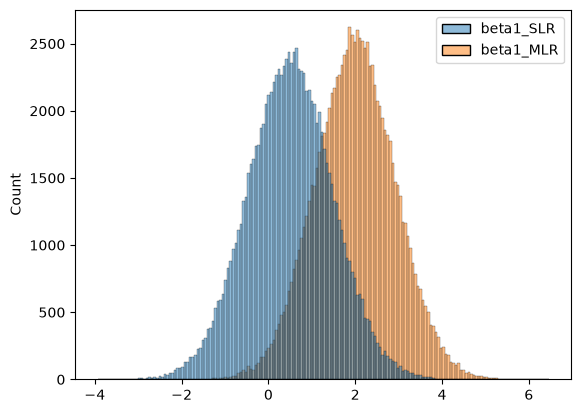

In [43]:
sns.histplot(results)